In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("Indian_Kids_Screen_Time.csv")
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [4]:
df.duplicated().sum()

np.int64(44)

In [5]:
df= df.drop_duplicates()

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3180
Urban_or_Rural                          0
dtype: int64

In [8]:
df["Health_Impacts"].fillna(df["Health_Impacts"].mode()[0],inplace=True)

In [9]:
df.isnull().sum()

Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64

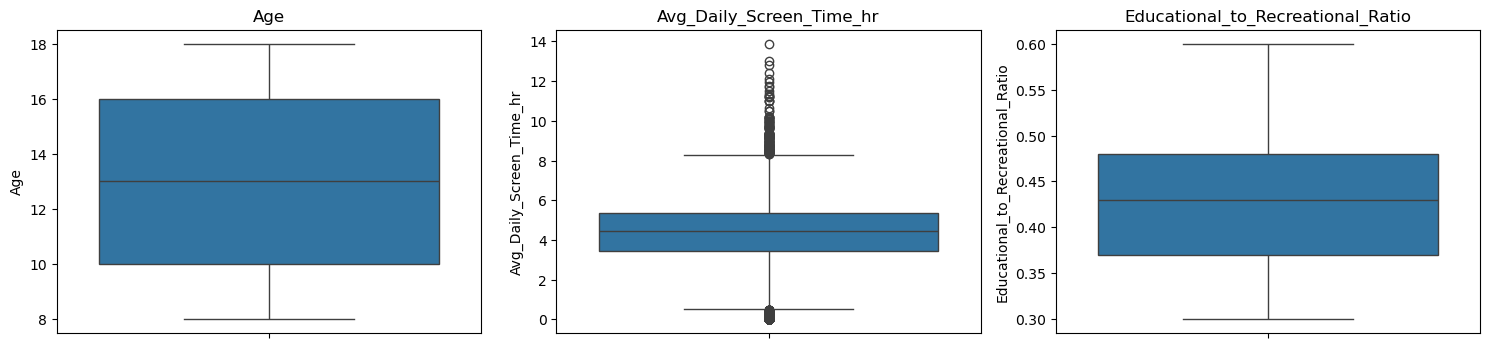

In [10]:
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

def cap_outliers(df, cols):
    df = df.copy()
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df[col] = df[col].clip(lower, upper)
    
    return df

df= cap_outliers(df, num_cols)

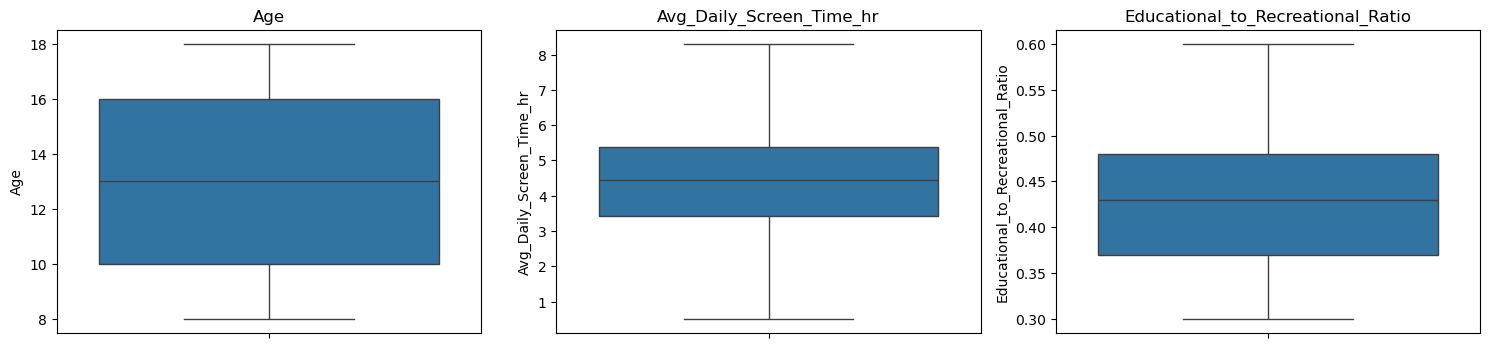

In [12]:
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9668 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9668 non-null   int64  
 1   Gender                             9668 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9668 non-null   float64
 3   Primary_Device                     9668 non-null   object 
 4   Exceeded_Recommended_Limit         9668 non-null   bool   
 5   Educational_to_Recreational_Ratio  9668 non-null   float64
 6   Health_Impacts                     9668 non-null   object 
 7   Urban_or_Rural                     9668 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 613.7+ KB


In [14]:
y=df["Avg_Daily_Screen_Time_hr"]

In [15]:
x=df.drop(["Avg_Daily_Screen_Time_hr"],axis=1)

In [16]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9668 entries, 0 to 9711
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9668 non-null   int64  
 1   Gender                             9668 non-null   object 
 2   Primary_Device                     9668 non-null   object 
 3   Exceeded_Recommended_Limit         9668 non-null   bool   
 4   Educational_to_Recreational_Ratio  9668 non-null   float64
 5   Health_Impacts                     9668 non-null   object 
 6   Urban_or_Rural                     9668 non-null   object 
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 538.2+ KB


In [31]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

ct = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(drop='first'), cat_cols),
        ("scaler", StandardScaler(), num_cols)
    ]
)
x_transformed = ct.fit_transform(x)

x_transformed = pd.DataFrame(x_transformed)

print(x_transformed)

ValueError: A given column is not a column of the dataframe

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [20]:
ct = ColumnTransformer( transformers=[("oe",OrdinalEncoder(),[1,2,3,5,6]),
                                   ("sc",StandardScaler(),[0,4])])

In [21]:
x_train_transform=ct.fit_transform(x_train)
x_tarin_transorm=pd.DataFrame(x_train_transform)

In [22]:
x_test_transform=ct.transform(x_test)
x_test_transform=pd.DataFrame(x_test_transform)

In [23]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

dt = DecisionTreeRegressor()

dt.fit(x_train_transform, y_train)

y_pred = dt.predict(x_test_transform)

mse = mean_squared_error(y_test, y_pred)
print(mse)

r2 = r2_score(y_test, y_pred)
print(r2)

2.5393090030143894
0.04015931996025068


In [25]:
dt = DecisionTreeRegressor()

dt.fit(x_train_transform,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [26]:
y_pred = dt.predict(x_test_transform)


In [27]:
mse = mean_squared_error(y_test, y_pred)

print(mse)

2.5232448428451226


In [28]:
r2 = r2_score(y_test, y_pred)

print(r2)

0.046231457853997515


In [29]:
from sklearn.model_selection import GridSearchCV
params = {
    "criterion":['squared_error'],
    "splitter":("best","random"),
    "max_depth":(list(range(1,10))),
    "min_samples_split":[2,3,4,5,6,7],
    "min_samples_leaf":list(range(1,5))
}
tree_clf = DecisionTreeRegressor()
tree_cv = GridSearchCV(tree_clf,params,scoring = 'r2',n_jobs = -1 , verbose = 2 , cv = 5)

In [30]:
tree_cv.fit(x_train,y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


ValueError: 
All the 2160 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
432 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\vinod\OneDrive\Documents\anaconda3_2\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vinod\OneDrive\Documents\anaconda3_2\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\vinod\OneDrive\Documents\anaconda3_2\Lib\site-packages\sklearn\tree\_classes.py", line 1404, in fit
    super()._fit(
    ~~~~~~~~~~~~^
        X,
        ^^
    ...<2 lines>...
        check_input=check_input,
        ^^^^^